In [9]:
import requests
from rdflib import Graph, URIRef, Literal, Namespace
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [10]:
#VIRTUOSO_URL = "http://localhost:8890/sparql-graph-crud"
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI = "http://example.com/Gent-Terneuzen"
USERNAME = "dba"
PASSWORD = "dba"
AUTH  = (USERNAME,PASSWORD)


In [11]:
params = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

In [12]:
LIMIT = 100000 
offset = 0
g = Graph()
time_series_data = [] 
df = pd.DataFrame()

# Identifying unique sensors

In [14]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT  DISTINCT ?sensor
    WHERE {{ 
        GRAPH <{GRAPH_URI}> {{ 
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }} 
    }} 
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
        print(f"Error: {res.status_code}")
        print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data = res.json()
bindings = data['results']['bindings']

for row in bindings:
    # Extract the URI string and add it to the set
    sensor_uri = row['sensor']['value']
    sensor_set.add(sensor_uri)

print(f"Added {len(sensor_set)} unique sensors to the set.")
print("Sensors:", sensor_set)


Unique sensors identified successfully!
Added 4 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289429042', 'http://example.com/waterinfo/289423042', 'http://example.com/waterinfo/289441042', 'http://example.com/waterinfo/289435042'}


In [7]:
# print("Fetching date-value pairs...")
# query = f"""
#     PREFIX sosa: <http://www.w3.org/ns/sosa/>
#     SELECT ?time ?value ?sensor
#     WHERE {{ 
#         GRAPH <{GRAPH_URI}> {{ 
#             ?obs a sosa:Observation ;
#                  sosa:resultTime ?time ;
#                  sosa:hasSimpleResult ?value ;
#                  sosa:madeBySensor ?sensor .
#         }} 
#     }} 
#     """
# res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})


# if res.status_code != 200:
#         print(f"Error: {res.status_code}")
#         print("Response:", res.text)
# else:
#     print("Data fetched successfully!")

# bindings = res.json()['results']['bindings']

# for row in bindings:
#     df = df.append({'time': row['time']['value'], 'value': float(row['value']['value']), 'sensor': row['sensor']['value']}, ignore_index=True)

# # df = pd.DataFrame([
# #         {'time': row['time']['value'], 'value': float(row['value']['value'])} 
# #         for row in bindings
# #     ])

# df['time'] = pd.to_datetime(df['time'])
# print("Finished!")

In [22]:


# 1. Initialize an empty DataFrame for the master table
# We will start with just the 'time' column or an empty DF
final_df = pd.DataFrame()

print("Fetching and pivoting sensor data...")

for sensor_uri in sensor_set:
    # Use the sensor URI (or just the ID part) as the column name
    column_name = sensor_uri.split('/')[-1] 
    
    query = f"""
        PREFIX sosa: <http://www.w3.org/ns/sosa/>
        SELECT ?time ?value
        WHERE {{ 
            GRAPH <{GRAPH_URI}> {{ 
                ?obs a sosa:Observation ;
                    sosa:resultTime ?time ;
                    sosa:hasSimpleResult ?value ;
                    sosa:madeBySensor <{sensor_uri}> .
            }} 
        }} 
    """
    res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})
    
    if res.status_code == 200:
        bindings = res.json()['results']['bindings']
        
        # 2. Create a temporary DF for THIS sensor
        temp_data = [
            {'time': row['time']['value'], column_name: float(row['value']['value'])} 
            for row in bindings
        ]
        temp_df = pd.DataFrame(temp_data)
        
        if not temp_df.empty:
            temp_df['time'] = pd.to_datetime(temp_df['time'])
            
            # 3. Merge this sensor into the final_df
            if final_df.empty:
                final_df = temp_df
            else:
                # 'outer' join ensures we keep timestamps even if some sensors are missing data
                final_df = pd.merge(final_df, temp_df, on='time', how='outer')
            
            print(f"Added column for sensor: {column_name}")

# 4. Final touches
final_df = final_df.sort_values('time').set_index('time')

print("Finished!")
print(final_df.head())

Fetching and pivoting sensor data...
Added column for sensor: 289429042
Added column for sensor: 289423042
Added column for sensor: 289441042
Added column for sensor: 289435042
Finished!
                           289429042  289423042  289441042  289435042
time                                                                 
2021-03-03 23:15:00+00:00    1605.77        NaN    4797.72    3606.54
2021-03-03 23:30:00+00:00        NaN        NaN    4717.80        NaN
2021-03-03 23:45:00+00:00    1602.34     902.27    4745.36    3556.45
2021-03-04 00:00:00+00:00    1611.26        NaN        NaN        NaN
2021-03-04 00:15:00+00:00    1614.24     901.96        NaN        NaN


# ARIMA models

## Auto correlation

# Random Forest

In [23]:
# Create a copy to avoid overwriting the original data
data = final_df.copy().sort_index()

# 1. Feature Engineering: Create Lags for ALL sensors
# This gives the model "context" of what happened 15 mins ago across the whole canal
for col in data.columns:
    data[f'{col}_lag1'] = data[col].shift(1)

# 2. Add Time Features (Periodicity)
data['hour'] = data.index.hour
data['day_of_week'] = data.index.dayofweek

# 3. Drop rows with NaNs (created by the shift)
data.dropna(inplace=True)

# 4. Define Target (What you want to predict) and Features
# Let's predict the NEXT value of the first sensor
target_sensor = data.columns[0] # e.g., 'sensor_A'

y = data[target_sensor]
X = data.drop(columns=[target_sensor]) # Use all lags and time features to predict it


Metric          Value
----------------------
MAE          457.0503
RMSE         990.1613
R²             0.9375


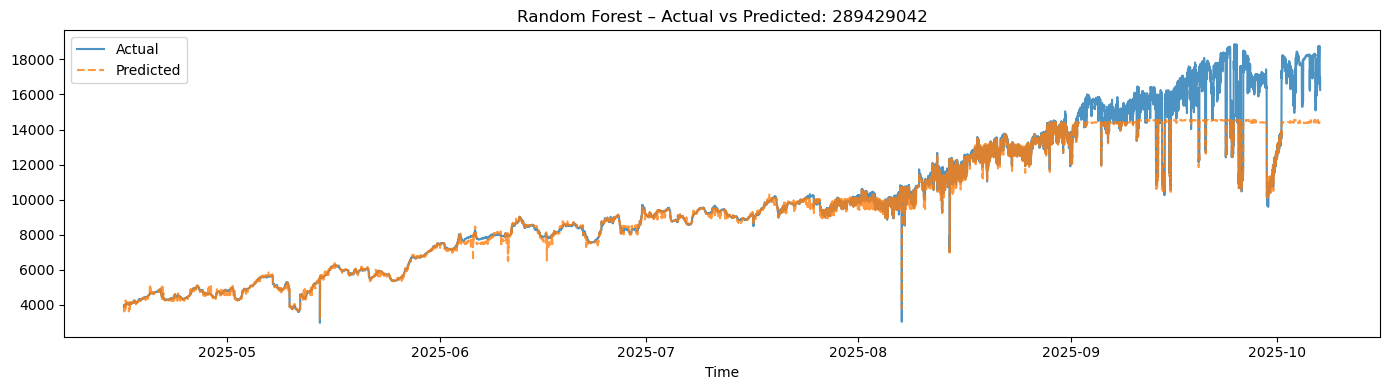

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Split at 70% mark
split_idx = int(len(data) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Initialize the Model
# n_estimators=100 is a good start; max_depth prevents overfitting
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# 3. Predict & Evaluate
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\n{'Metric':<10} {'Value':>10}")
print("-" * 22)
print(f"{'MAE':<10} {mae:>10.4f}")
print(f"{'RMSE':<10} {rmse:>10.4f}")
print(f"{'R²':<10} {r2:>10.4f}")

# 4. Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test.index, y_test.values,  label='Actual',    alpha=0.8)
ax.plot(y_test.index, y_pred,          label='Predicted', alpha=0.8, linestyle='--')
ax.set_title(f'Random Forest – Actual vs Predicted: {target_sensor}')
ax.set_xlabel('Time')
ax.legend()
plt.tight_layout()
plt.show()

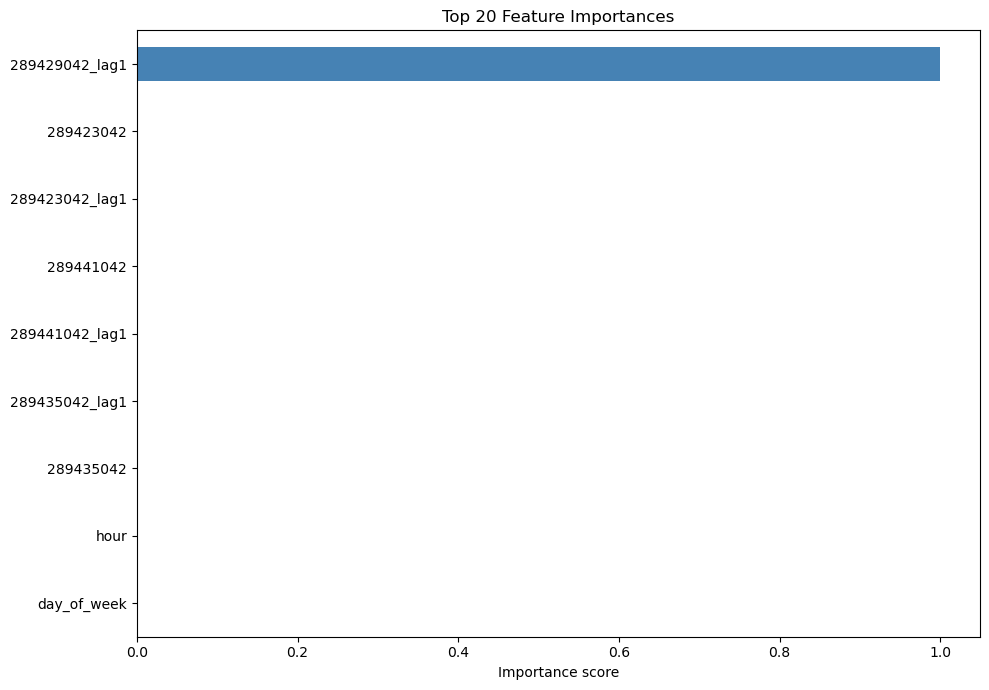

In [27]:
# ── Feature Importance ───────────────────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_n = importances.nlargest(20)   # show top 20 only — cleaner chart

fig, ax = plt.subplots(figsize=(10, 7))
top_n.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()
